In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("../data/raw/wearable_health_devices.csv")
df.head()

,user_id,date,age,gender,region,device_model,height_cm,weight_kg,bmi,resting_hr_bpm,...,sleep_duration_hours,sleep_efficiency,sleep_latency_min,wake_after_sleep_onset_min,sleep_stage_rem_pct,sleep_stage_deep_pct,sleep_stage_light_pct,stress_score,mindfulness_minutes,mood
0,U0001,2025-05-11,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,71.481219,...,6.846974,0.915716,14.0,39.0,0.289,0.144,0.567,55,3,bad
1,U0001,2025-05-12,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,67.964498,...,7.103551,0.944442,25.0,38.0,0.209,0.204,0.588,58,0,very_bad
2,U0001,2025-05-13,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,66.760038,...,7.954798,0.859938,19.0,32.0,0.203,0.189,0.608,50,8,good
3,U0001,2025-05-14,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,65.008374,...,7.375435,0.970183,12.0,40.0,0.211,0.159,0.630,54,12,neutral
4,U0001,2025-05-15,35,female,TR-EasternAnatolia,FitPulse X,170,58.7,20.3,67.528909,...,7.569236,0.916390,8.0,23.0,0.236,0.206,0.558,55,0,neutral


In [4]:
df["stress_score"].describe()

count    55200.000000
mean        67.035163
std         11.751781
min         19.000000
25%         59.000000
50%         67.000000
75%         75.000000
max        100.000000
Name: stress_score, dtype: float64

In [5]:
df["stress_score"].value_counts().sort_index()

stress_score
19       1
20       2
22       2
24       1
25       2
      ... 
96      79
97      73
98      59
99      49
100    168
Name: count, Length: 80, dtype: int64

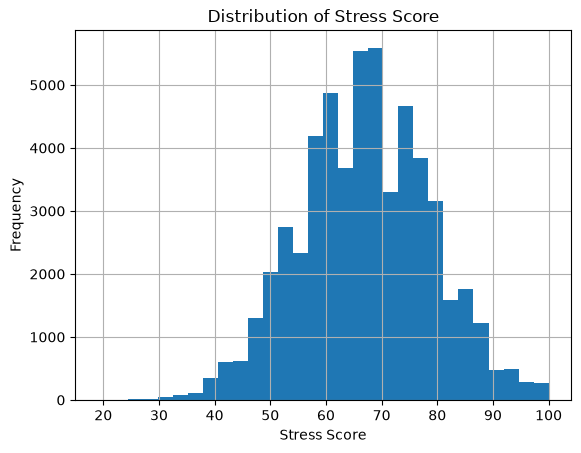

In [6]:
df["stress_score"].hist(bins=30)

plt.xlabel("Stress Score")
plt.ylabel("Frequency")
plt.title("Distribution of Stress Score")
plt.show()

In [7]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'height_cm', 'weight_kg', 'bmi', 'resting_hr_bpm', 'avg_hr_day_bpm', 'hrv_rmssd_ms', 'spo2_avg_pct', 'sbp_mmHg', 'dbp_mmHg', 'steps', 'distance_km', 'calories_kcal', 'workout_minutes', 'caffeine_mg', 'alcohol_units', 'screen_time_min', 'sleep_duration_hours', 'sleep_efficiency', 'sleep_latency_min', 'wake_after_sleep_onset_min', 'sleep_stage_rem_pct', 'sleep_stage_deep_pct', 'sleep_stage_light_pct', 'stress_score', 'mindfulness_minutes']

Categorical columns:
['user_id', 'date', 'gender', 'region', 'device_model', 'workout_type', 'mood']


C:\Users\hp\AppData\Local\Temp\ipykernel_23260\1372586168.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [8]:
stress_corr = (
    df.select_dtypes(include="number")
      .corr()["stress_score"]
      .sort_values(ascending=False)
)

stress_corr.drop("stress_score")

screen_time_min               0.310651
caffeine_mg                   0.305081
alcohol_units                 0.261076
sleep_stage_light_pct         0.188583
wake_after_sleep_onset_min    0.139404
sleep_latency_min             0.133804
age                           0.074153
sbp_mmHg                      0.052138
bmi                           0.045825
weight_kg                     0.043869
dbp_mmHg                      0.028474
resting_hr_bpm                0.027237
avg_hr_day_bpm                0.017478
sleep_stage_rem_pct           0.003519
height_cm                    -0.013413
workout_minutes              -0.037649
spo2_avg_pct                 -0.037938
mindfulness_minutes          -0.070261
calories_kcal                -0.213708
sleep_stage_deep_pct         -0.225564
sleep_efficiency             -0.310545
distance_km                  -0.321643
steps                        -0.325982
hrv_rmssd_ms                 -0.507283
sleep_duration_hours         -0.630609
Name: stress_score, dtype

In [9]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- user_id ---
user_id
U0001    184
U0002    184
U0003    184
U0004    184
U0005    184
        ... 
U0296    184
U0297    184
U0298    184
U0299    184
U0300    184
Name: count, Length: 300, dtype: int64

--- date ---
date
2025-05-11    300
2025-05-12    300
2025-05-13    300
2025-05-14    300
2025-05-15    300
             ... 
2025-11-06    300
2025-11-07    300
2025-11-08    300
2025-11-09    300
2025-11-10    300
Name: count, Length: 184, dtype: int64

--- gender ---
gender
female    27600
male      27232
other       368
Name: count, dtype: int64

--- region ---
region
TR-Aegean             9752
TR-BlackSea           8648
TR-Southeastern       8096
TR-EasternAnatolia    7912
TR-Marmara            7912
TR-Mediterranean      6992
TR-CentralAnatolia    5888
Name: count, dtype: int64

--- device_model ---
device_model
SleepSense 2      12696
FitPulse X        12328
HealthBand Pro    10672
PulseOne Mini     10304
VitalWatch 4       9200
Name: count, dtype: int64

--- workout_type ---

In [10]:
numeric_features = df.select_dtypes(include="number").drop(
    columns=["stress_score"]
)

corr_matrix = numeric_features.corr()

In [11]:
high_corr_pairs = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append(
                (columns[i], columns[j], corr_value)
            )

high_corr_pairs

[('weight_kg', 'bmi', np.float64(0.8083256639664812)),
 ('steps', 'distance_km', np.float64(0.9838368196679046)),
 ('steps', 'sleep_efficiency', np.float64(0.8308577153576687)),
 ('distance_km', 'sleep_efficiency', np.float64(0.8170481107121658)),
 ('sleep_stage_deep_pct',
  'sleep_stage_light_pct',
  np.float64(-0.8276813160453427))]

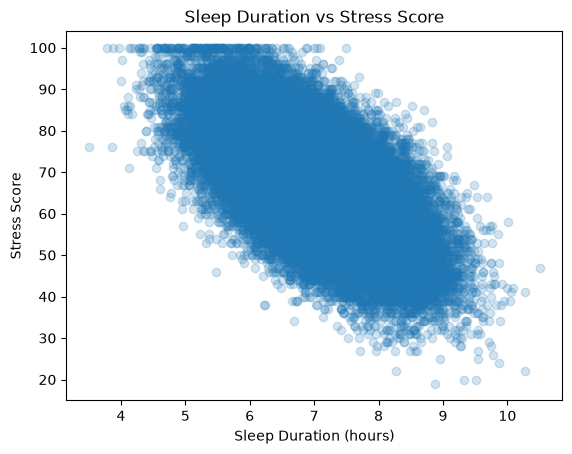

In [12]:
plt.scatter(
    df["sleep_duration_hours"],
    df["stress_score"],
    alpha=0.2
)

plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Stress Score")
plt.title("Sleep Duration vs Stress Score")
plt.show()

In [13]:
df.groupby("mood")["stress_score"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean")

,count,mean,median,min,max
mood,,,,,
very_good,374,42.379679,42.0,20,62
good,3543,50.278013,50.0,19,77
neutral,13548,58.854148,59.0,27,87
bad,20773,67.046743,67.0,34,100
very_bad,16962,77.599222,77.0,47,100


In [14]:
sleep_stage_total = (
    df["sleep_stage_deep_pct"]
    + df["sleep_stage_light_pct"]
    + df["sleep_stage_rem_pct"]
)

sleep_stage_total.describe()


count    54143.000000
mean         1.000001
std          0.000501
min          0.999000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.001000
dtype: float64

In [15]:
df["stress_class_temp"] = pd.cut(
    df["stress_score"],
    bins=[-float("inf"), 33, 66, float("inf")],
    labels=["Low", "Moderate", "High"]
)

df["stress_class_temp"].value_counts()

stress_class_temp
High        28492
Moderate    26599
Low           109
Name: count, dtype: int64

Shows that uniform binning creates an extremely imbalanced class distribution (only 109 in Low, but ~28.5k in High).

In [16]:
df["stress_score"].quantile([0, 0.25, 0.33, 0.50, 0.67, 0.75, 1.0])

0.00     19.0
0.25     59.0
0.33     62.0
0.50     67.0
0.67     72.0
0.75     75.0
1.00    100.0
Name: stress_score, dtype: float64

In [17]:
df["stress_class_temp"] = pd.qcut(
    df["stress_score"],
    q=3,
    labels=["Low", "Moderate", "High"]
)

df["stress_class_temp"].value_counts()

stress_class_temp
Low         19322
Moderate    18116
High        17762
Name: count, dtype: int64

In [18]:
pd.qcut(
    df["stress_score"],
    q=3,
    retbins=True
)

(0        (18.999, 62.0]
 1        (18.999, 62.0]
 2        (18.999, 62.0]
 3        (18.999, 62.0]
 4        (18.999, 62.0]
               ...      
 55195    (18.999, 62.0]
 55196      (62.0, 72.0]
 55197      (62.0, 72.0]
 55198     (72.0, 100.0]
 55199     (72.0, 100.0]
 Name: stress_score, Length: 55200, dtype: category
 Categories (3, interval[float64, right]): [(18.999, 62.0] < (62.0, 72.0] < (72.0, 100.0]],
 array([ 19.,  62.,  72., 100.]))

In [19]:
df["stress_class"] = pd.cut(
    df["stress_score"],
    bins=[18, 62, 72, 100],
    labels=["Low", "Moderate", "High"],
    include_lowest=True
)

df["stress_class"].value_counts()

stress_class
Low         19322
Moderate    18116
High        17762
Name: count, dtype: int64